## MLP - Actividades de modificación

En esta notebook se evalúan las modificaciones pedidas en `Preguntas.md`:

- Dropout;
- Batch Normalization;
- Weight Decay;
- Data Augmentation;
- Early Stopping;
- inicialización Xavier;
- inicialización He/Kaiming;
- inicialización uniforme;
- logging con TensorBoard;
- visualización de histogramas de pesos.

El test fijo se mantiene excluido. Todas las comparaciones se hacen con 5-fold cross-validation sobre `trainval`.

In [1]:
# ============================================================
# 1. Configuración de paths
# ============================================================

from pathlib import Path
import sys
import os
import json
import pandas as pd

REPO_ROOT = Path.cwd()

if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
sys.path.append(str(REPO_ROOT / "src"))

print(f"Repo root: {REPO_ROOT}")

# ============================================================
# 2. Importar funciones de entrenamiento
# ============================================================

from mlp_training import run_cross_validation, save_experiment_outputs

Repo root: c:\Users\tomas\OneDrive\Documentos\MATERIAS ITBA\ELECTIVAS - CUATRIMESTRE X\MACHINE LEARNING y REDES NEURONALES EN BIOINGENIERÍA\skin-dataset-classification


In [2]:
# ============================================================
# 3. Definición de experimentos
# ============================================================
#
# La lógica es acumulativa:
#
# MLP_1:
#   agrega Dropout.
#
# MLP_2:
#   agrega BatchNorm además de Dropout.
#
# MLP_3:
#   agrega Weight Decay además de Dropout + BatchNorm.
#
# MLP_4:
#   agrega Data Augmentation.
#
# MLP_5, MLP_6, MLP_7:
#   comparan inicializaciones manuales:
#   Xavier, He/Kaiming y uniforme.
#
# MLP_8:
#   prueba Early Stopping.
#
# Todos usan el mismo split final y la misma validación cruzada.
# ============================================================

experiments = [
    {
        "experiment": "MLP_1_dropout",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": False,
        "weight_decay": 0.0,
        "augmentation": "minimal",

        "initialization": "default",

        "early_stopping": False,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
    {
        "experiment": "MLP_2_dropout_batchnorm",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": True,
        "weight_decay": 0.0,
        "augmentation": "minimal",

        "initialization": "default",

        "early_stopping": False,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
    {
        "experiment": "MLP_3_dropout_batchnorm_weightdecay",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": True,
        "weight_decay": 1e-4,
        "augmentation": "minimal",

        "initialization": "default",

        "early_stopping": False,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
    {
        "experiment": "MLP_4_data_augmentation",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": True,
        "weight_decay": 1e-4,
        "augmentation": "medium",

        "initialization": "default",

        "early_stopping": False,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
    {
        "experiment": "MLP_5_xavier_initialization",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": True,
        "weight_decay": 1e-4,
        "augmentation": "medium",

        "initialization": "xavier",

        "early_stopping": False,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
    {
        "experiment": "MLP_6_he_initialization",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": True,
        "weight_decay": 1e-4,
        "augmentation": "medium",

        "initialization": "he",

        "early_stopping": False,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
    {
        "experiment": "MLP_7_uniform_initialization",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 20,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": True,
        "weight_decay": 1e-4,
        "augmentation": "medium",

        "initialization": "uniform",

        "early_stopping": False,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
    {
        "experiment": "MLP_8_early_stopping",
        "image_size": 64,
        "batch_size": 32,
        "epochs": 30,
        "lr": 1e-3,

        "dropout": 0.5,
        "batch_norm": True,
        "weight_decay": 1e-4,
        "augmentation": "medium",

        "initialization": "he",

        "early_stopping": True,
        "patience": 5,

        "tensorboard": True,
        "histogram_every": 5,
        "seed": 42,
    },
]


##########################################################################################
Ejecutando experimento: MLP_1_dropout
##########################################################################################
Experimento: MLP_1_dropout
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5000 | macro_f1=0.4623

Entrenando fold 1
Fold 1 terminado | val_acc=0.4792 | macro_f1=0.4877

Entrenando fold 2
Fold 2 terminado | val_acc=0.5245 | macro_f1=0.5167

Entrenando fold 3
Fold 3 terminado | val_acc=0.4755 | macro_f1=0.4427

Entrenando fold 4
Fold 4 terminado | val_acc=0.4965 | macro_f1=0.4974


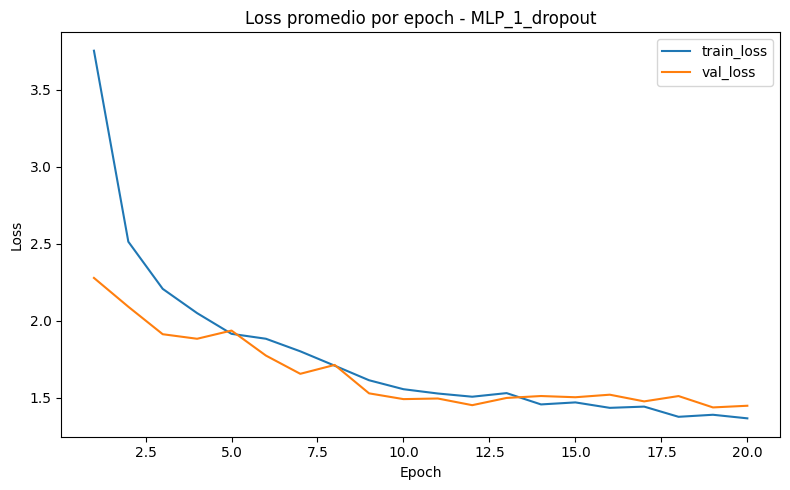

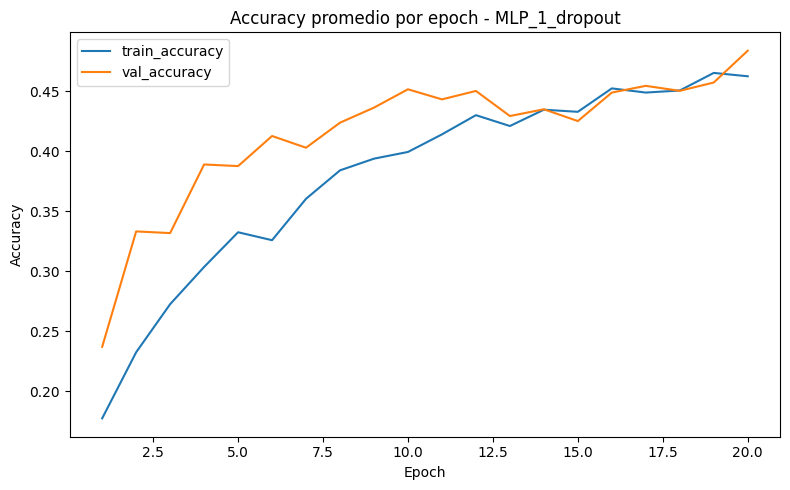

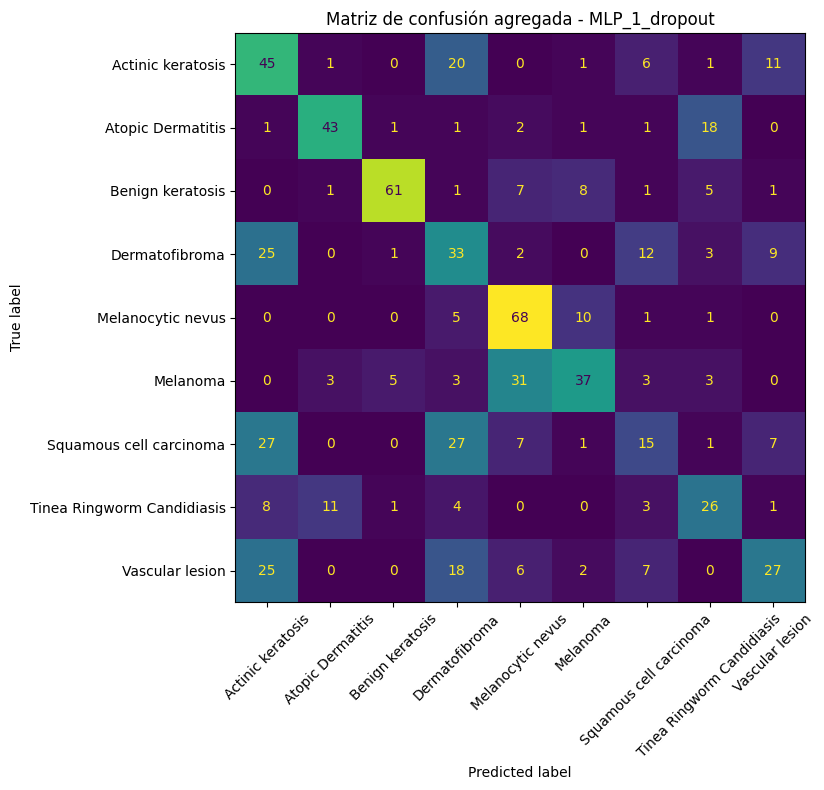

Guardado: experiments\mlp_1_dropout_fold_results.csv
Guardado: experiments\mlp_1_dropout_history.csv
Guardado: experiments\mlp_1_dropout_summary.json
Guardado: results\classification_reports\mlp_1_dropout_classification_report.txt

##########################################################################################
Ejecutando experimento: MLP_2_dropout_batchnorm
##########################################################################################
Experimento: MLP_2_dropout_batchnorm
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5833 | macro_f1=0.5605

Entrenando fold 1
Fold 1 terminado | val_acc=0.6111 | macro_f1=0.6209

Entrenando fold 2
Fold 2 terminado | val_acc=0.6084 | macro_f1=

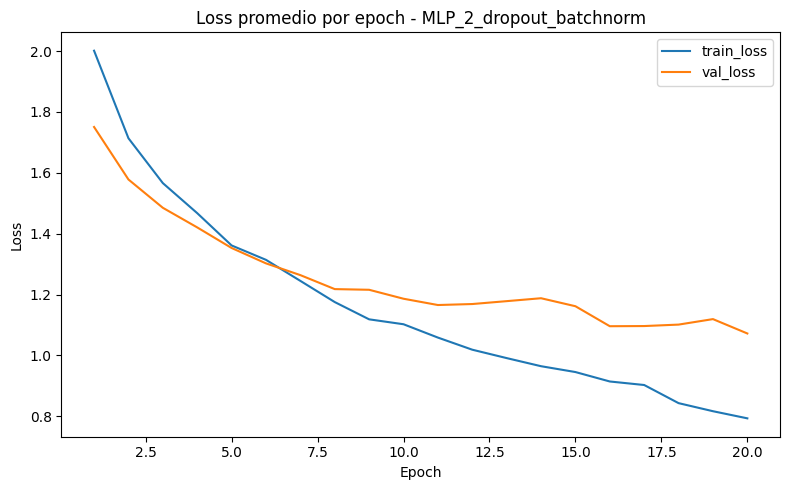

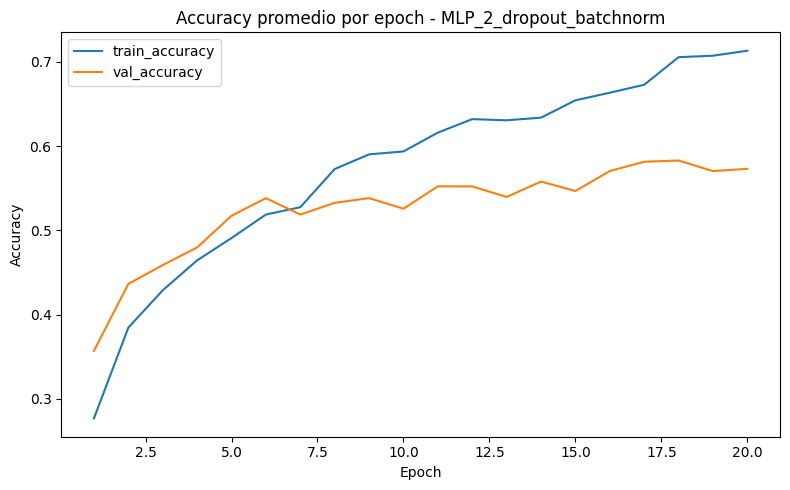

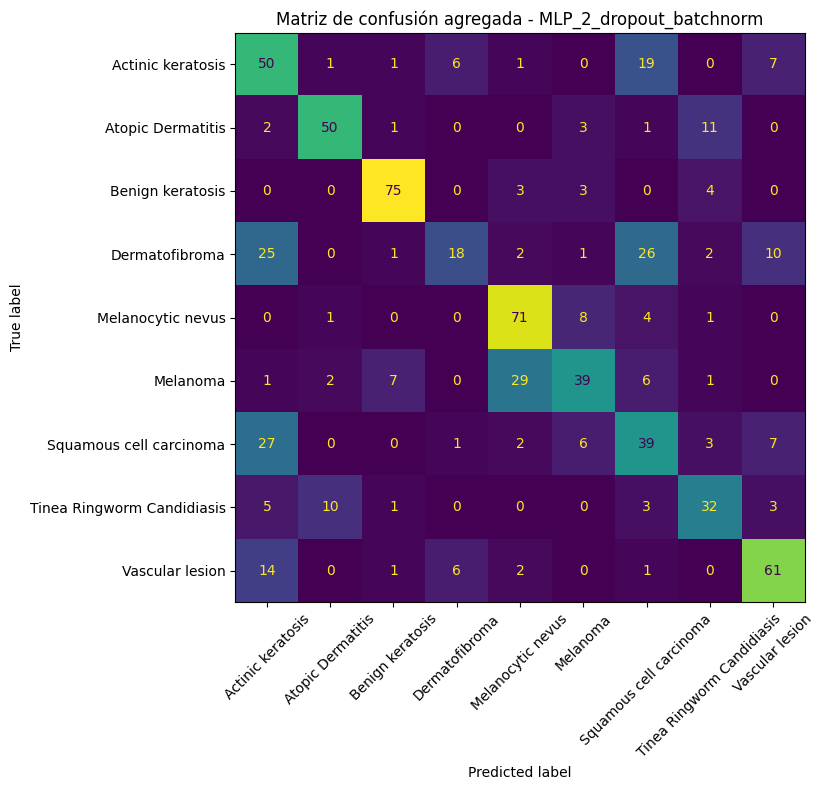

Guardado: experiments\mlp_2_dropout_batchnorm_fold_results.csv
Guardado: experiments\mlp_2_dropout_batchnorm_history.csv
Guardado: experiments\mlp_2_dropout_batchnorm_summary.json
Guardado: results\classification_reports\mlp_2_dropout_batchnorm_classification_report.txt

##########################################################################################
Ejecutando experimento: MLP_3_dropout_batchnorm_weightdecay
##########################################################################################
Experimento: MLP_3_dropout_batchnorm_weightdecay
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5903 | macro_f1=0.5326

Entrenando fold 1
Fold 1 terminado | val_acc=0.6528 | macro_f1=0.6633


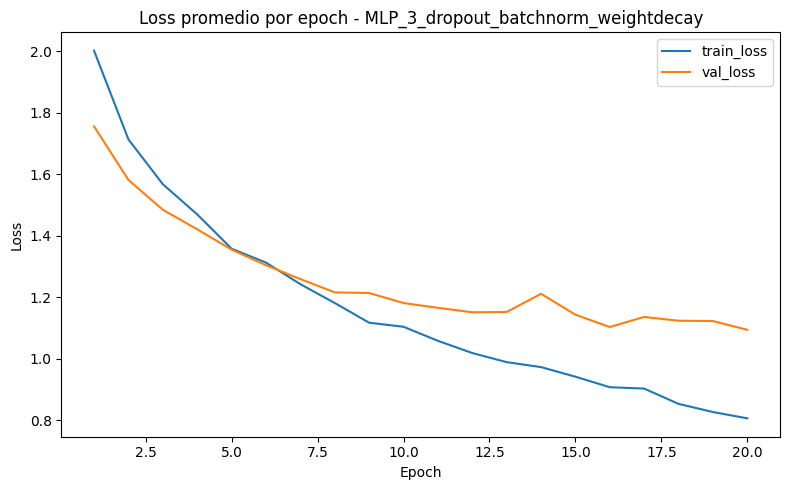

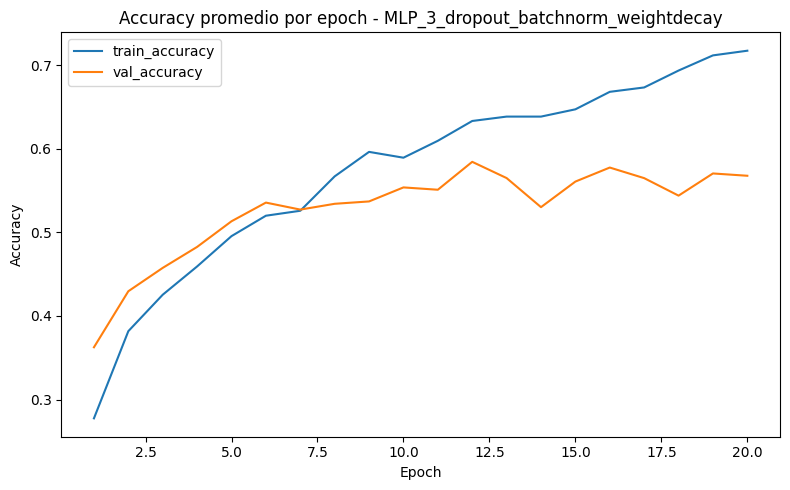

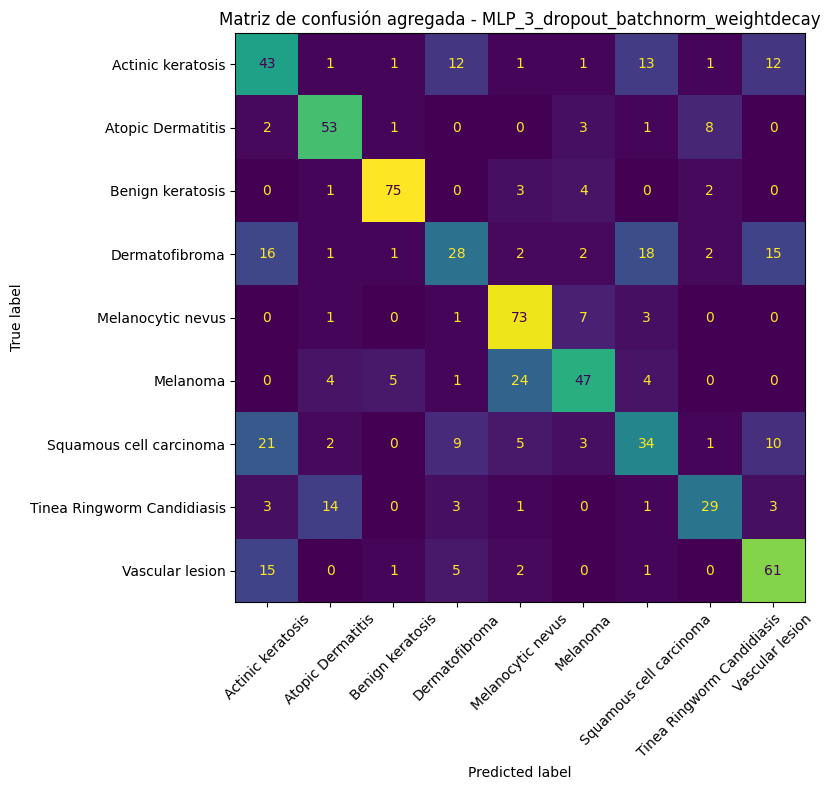

Guardado: experiments\mlp_3_dropout_batchnorm_weightdecay_fold_results.csv
Guardado: experiments\mlp_3_dropout_batchnorm_weightdecay_history.csv
Guardado: experiments\mlp_3_dropout_batchnorm_weightdecay_summary.json
Guardado: results\classification_reports\mlp_3_dropout_batchnorm_weightdecay_classification_report.txt

##########################################################################################
Ejecutando experimento: MLP_4_data_augmentation
##########################################################################################
Experimento: MLP_4_data_augmentation
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5278 | macro_f1=0.5063

Entrenando fold 1
Fold 1 terminado | val_acc=0

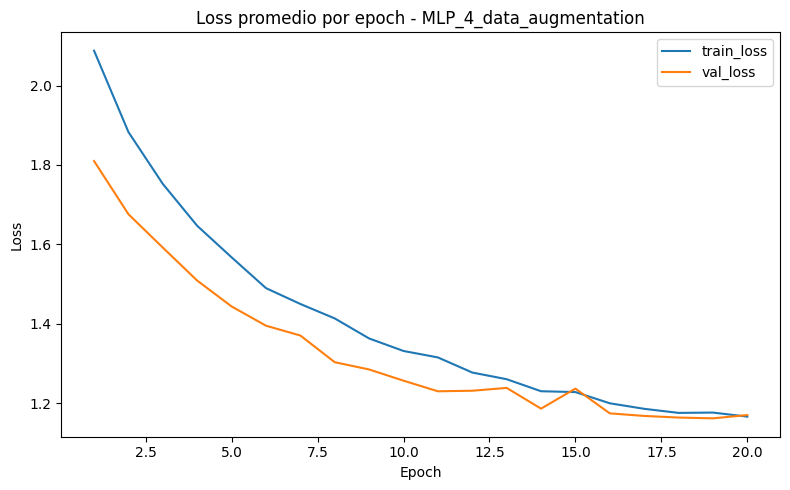

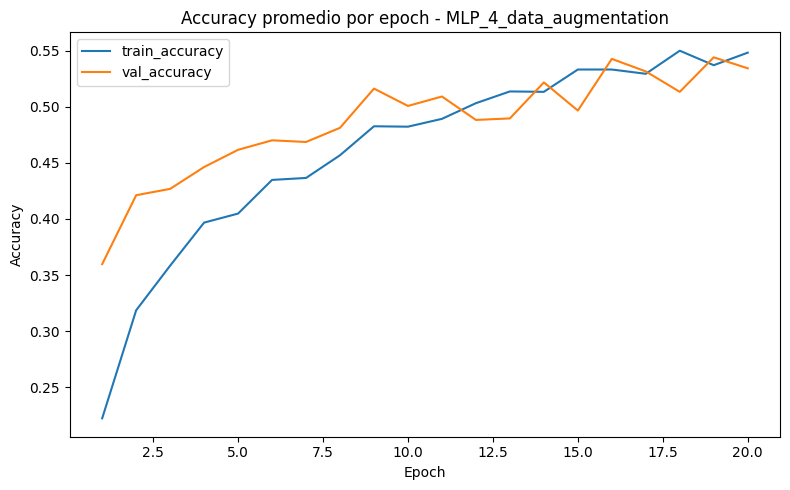

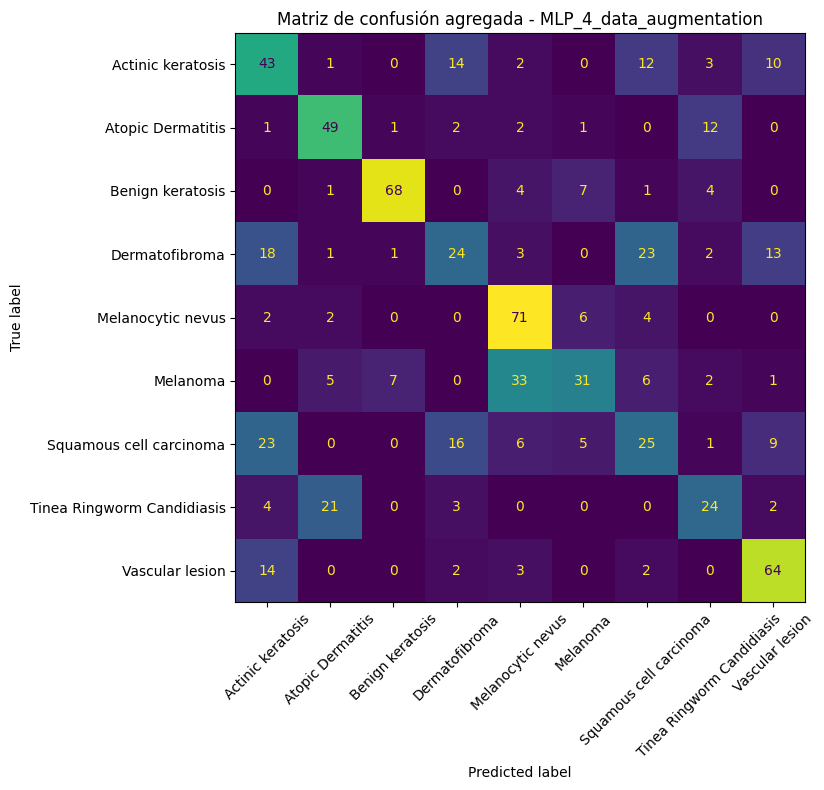

Guardado: experiments\mlp_4_data_augmentation_fold_results.csv
Guardado: experiments\mlp_4_data_augmentation_history.csv
Guardado: experiments\mlp_4_data_augmentation_summary.json
Guardado: results\classification_reports\mlp_4_data_augmentation_classification_report.txt

##########################################################################################
Ejecutando experimento: MLP_5_xavier_initialization
##########################################################################################
Experimento: MLP_5_xavier_initialization
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5556 | macro_f1=0.5302

Entrenando fold 1
Fold 1 terminado | val_acc=0.5556 | macro_f1=0.5525

Entrenando fold

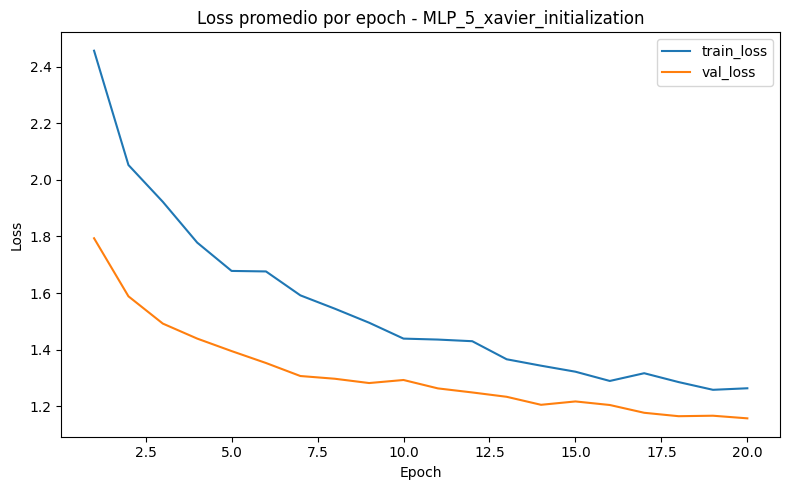

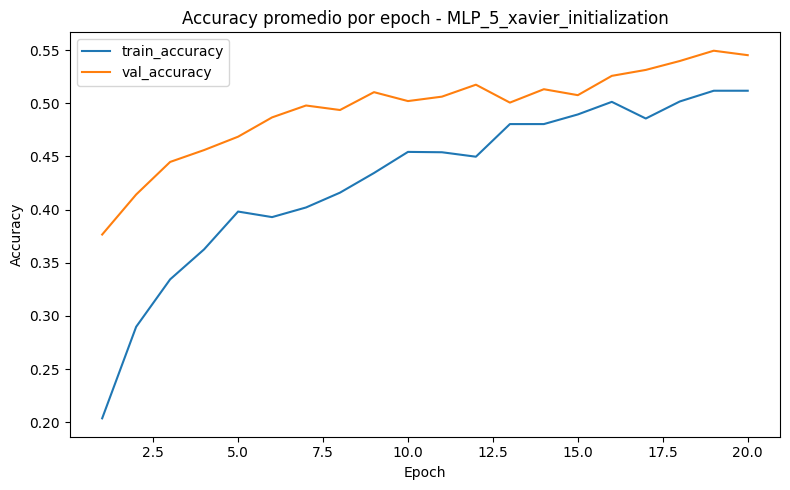

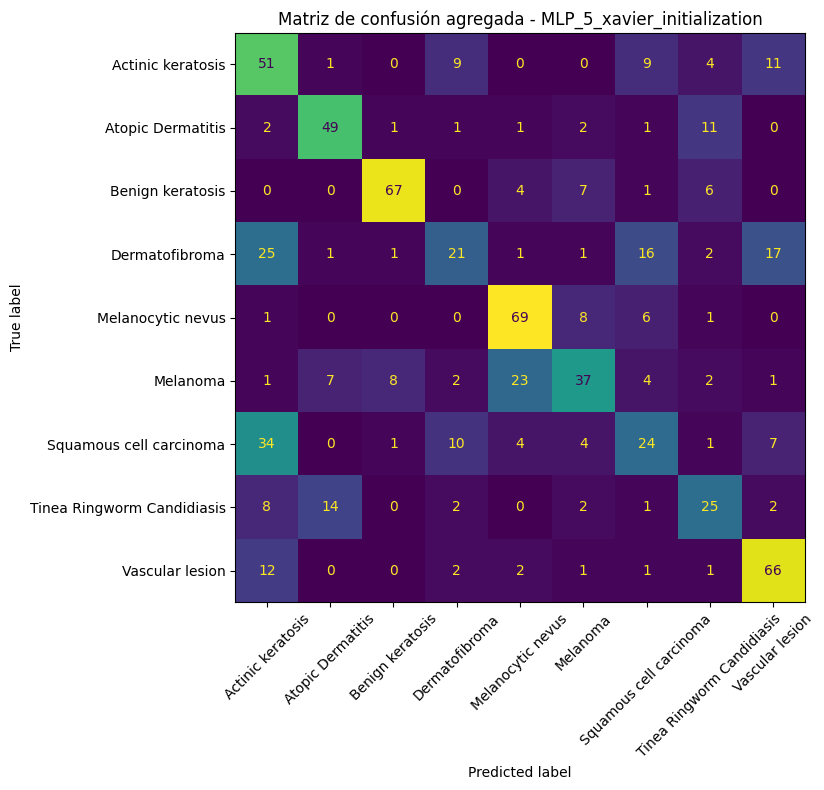

Guardado: experiments\mlp_5_xavier_initialization_fold_results.csv
Guardado: experiments\mlp_5_xavier_initialization_history.csv
Guardado: experiments\mlp_5_xavier_initialization_summary.json
Guardado: results\classification_reports\mlp_5_xavier_initialization_classification_report.txt

##########################################################################################
Ejecutando experimento: MLP_6_he_initialization
##########################################################################################
Experimento: MLP_6_he_initialization
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5486 | macro_f1=0.5293

Entrenando fold 1
Fold 1 terminado | val_acc=0.5764 | macro_f1=0.5634

Entrena

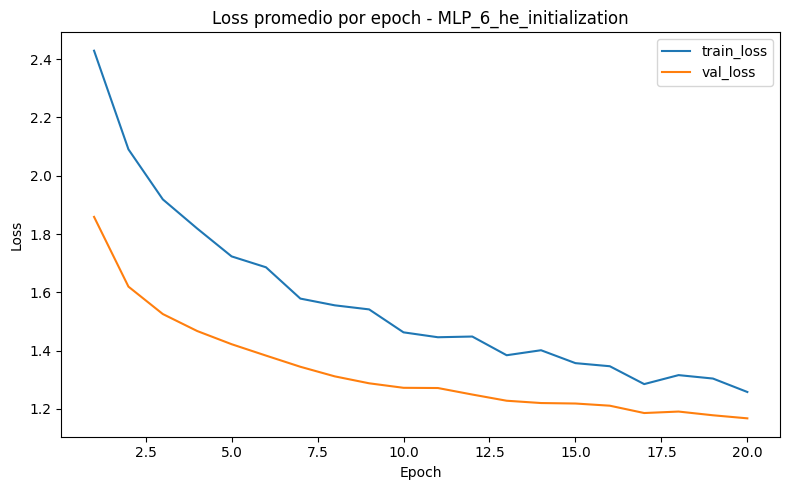

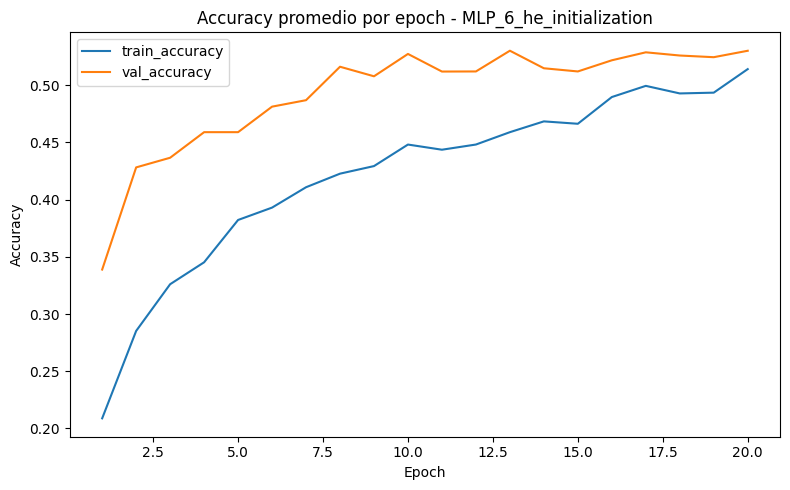

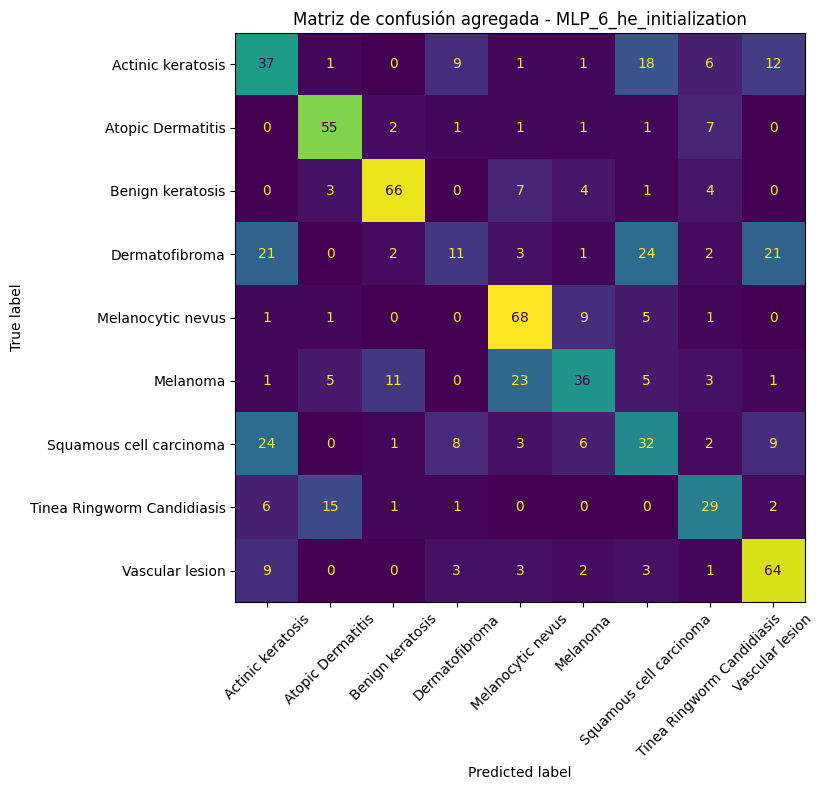

Guardado: experiments\mlp_6_he_initialization_fold_results.csv
Guardado: experiments\mlp_6_he_initialization_history.csv
Guardado: experiments\mlp_6_he_initialization_summary.json
Guardado: results\classification_reports\mlp_6_he_initialization_classification_report.txt

##########################################################################################
Ejecutando experimento: MLP_7_uniform_initialization
##########################################################################################
Experimento: MLP_7_uniform_initialization
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Fold 0 terminado | val_acc=0.5347 | macro_f1=0.5008

Entrenando fold 1
Fold 1 terminado | val_acc=0.5972 | macro_f1=0.6062

Entrenando fo

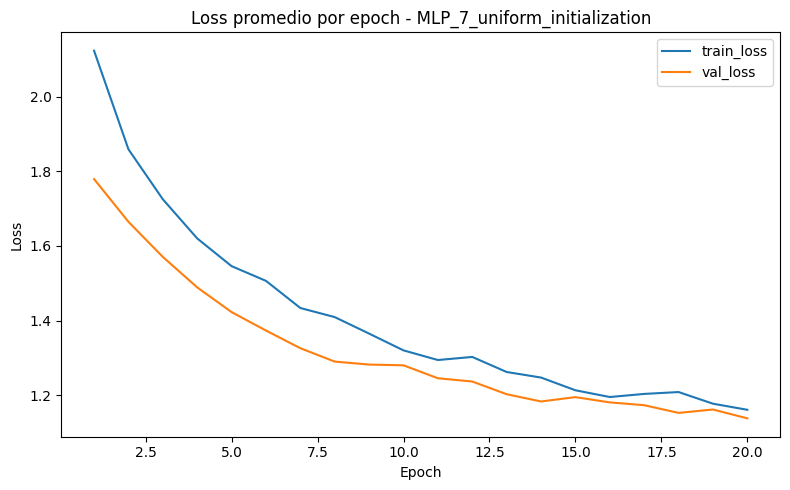

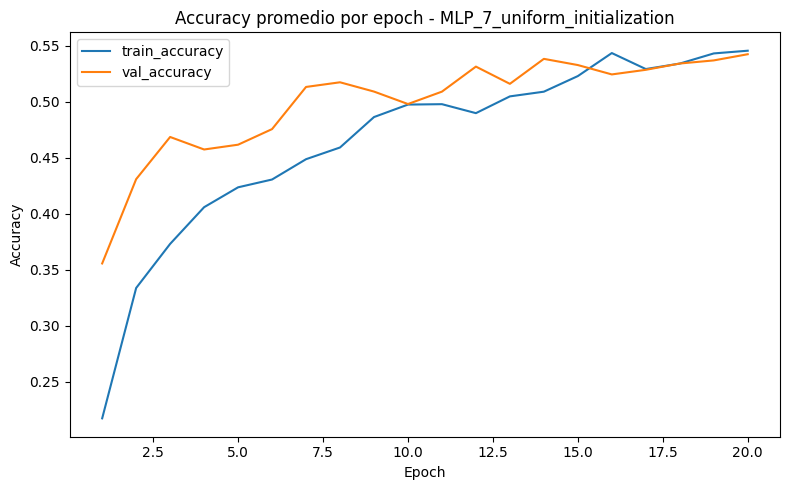

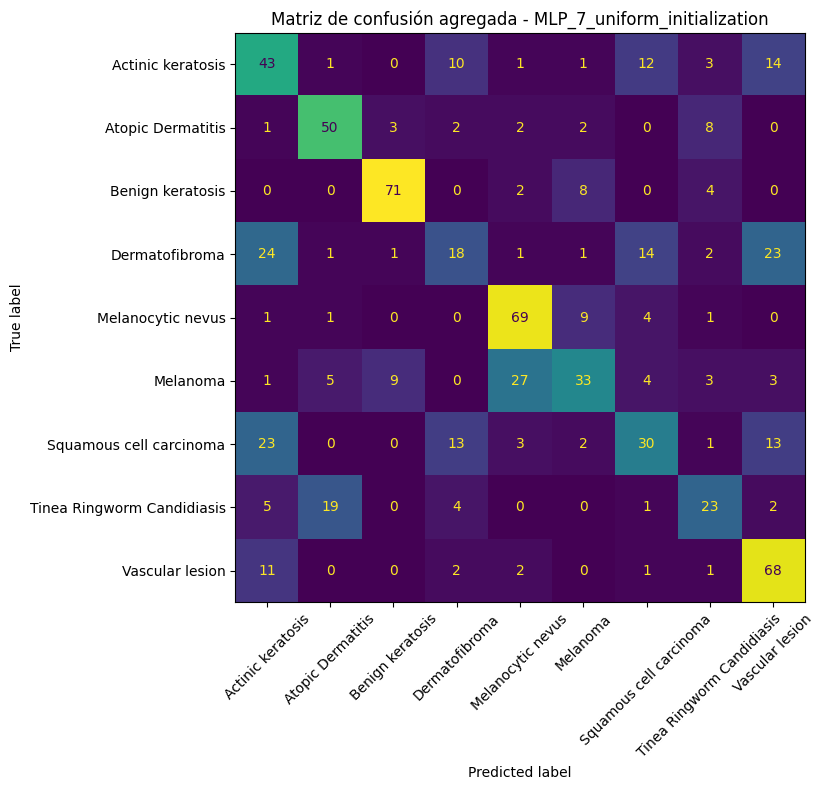

Guardado: experiments\mlp_7_uniform_initialization_fold_results.csv
Guardado: experiments\mlp_7_uniform_initialization_history.csv
Guardado: experiments\mlp_7_uniform_initialization_summary.json
Guardado: results\classification_reports\mlp_7_uniform_initialization_classification_report.txt

##########################################################################################
Ejecutando experimento: MLP_8_early_stopping
##########################################################################################
Experimento: MLP_8_early_stopping
Dispositivo: cpu
Folds usados: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Clases: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']

Entrenando fold 0
Early stopping en fold 0, epoch 7. Mejor epoch: 2
Fold 0 terminado | val_acc=0.5069 | macro_f1=0.4577

Entrenando fold 1
Early stoppi

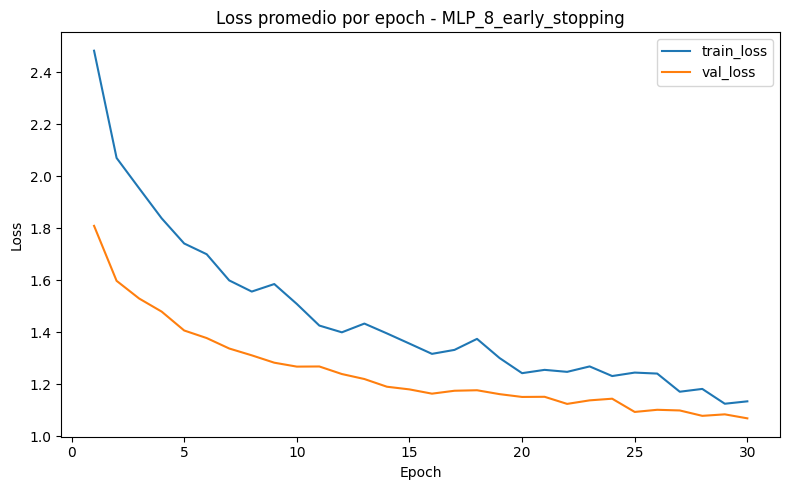

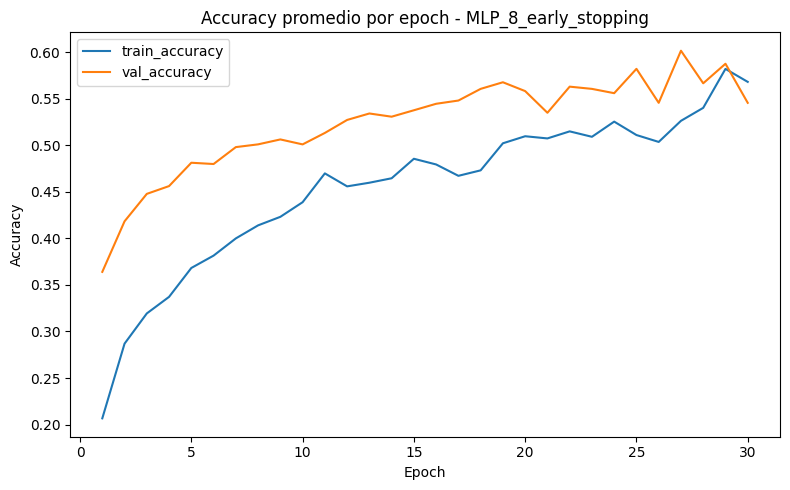

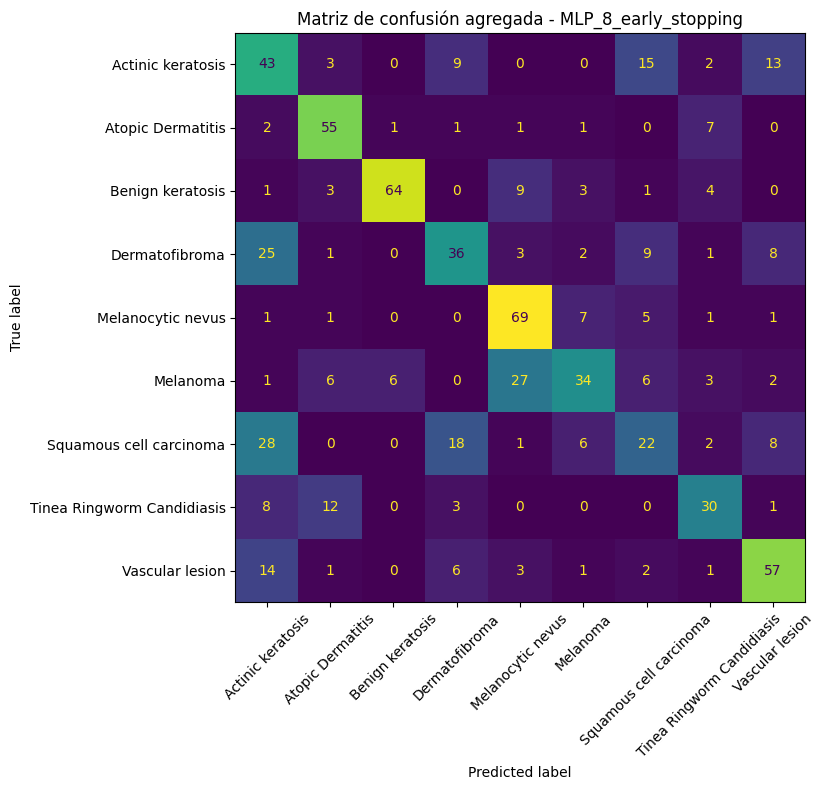

Guardado: experiments\mlp_8_early_stopping_fold_results.csv
Guardado: experiments\mlp_8_early_stopping_history.csv
Guardado: experiments\mlp_8_early_stopping_summary.json
Guardado: results\classification_reports\mlp_8_early_stopping_classification_report.txt


In [3]:
# ============================================================
# 4. Ejecutar experimentos
# ============================================================
#
# Cada experimento corre 5 folds.
#
# Esto puede tardar más que el baseline, pero sigue siendo MLP,
# no CNN. Si una corrida se interrumpe, se puede volver a correr
# esta celda; los archivos se sobrescriben.
# ============================================================

all_outputs = []
summary_rows = []

for config in experiments:
    print("\n" + "#" * 90)
    print(f"Ejecutando experimento: {config['experiment']}")
    print("#" * 90)

    output = run_cross_validation(
        config=config,
        split_csv="data/splits/final_split_5fold.csv",
    )

    all_outputs.append(output)
    summary_rows.append(output["summary"])

    save_experiment_outputs(
        cv_output=output,
        output_prefix=config["experiment"].lower(),
    )

In [4]:
# ============================================================
# 5. Cargar resumen del baseline
# ============================================================
#
# El baseline se entrenó en 01_MLP_baseline.ipynb.
# Para comparar todo junto, cargamos su summary.json.
# ============================================================

baseline_summary_path = Path("experiments/mlp_0_baseline_summary.json")

if baseline_summary_path.exists():
    with open(baseline_summary_path, "r", encoding="utf-8") as f:
        baseline_summary = json.load(f)

    all_summaries = [baseline_summary] + summary_rows

else:
    print("No se encontró el baseline. Se comparan solo las modificaciones.")
    all_summaries = summary_rows

In [5]:
# ============================================================
# 6. Tabla comparativa
# ============================================================
#
# Ordenamos por val_accuracy_mean.
# También conviene mirar macro_f1 y balanced_accuracy, porque puede
# haber desbalance de clases.
# ============================================================

summary_df = pd.DataFrame(all_summaries)

summary_df = summary_df.sort_values(
    by="val_accuracy_mean",
    ascending=False,
).reset_index(drop=True)

display(summary_df)

# ============================================================
# 7. Guardar comparación final de MLP
# ============================================================

output_csv = Path("experiments/experiments_mlp.csv")
summary_df.to_csv(output_csv, index=False)

print(f"Comparación MLP guardada en: {output_csv}")

,experiment,image_size,batch_size,epochs,lr,dropout,batch_norm,weight_decay,augmentation,initialization,early_stopping,val_accuracy_mean,val_accuracy_std,val_macro_f1_mean,val_macro_f1_std,val_balanced_accuracy_mean,val_balanced_accuracy_std
0,MLP_3_dropout_batchnorm_weightdecay,64,32,20,0.001,0.5,True,0.0001,minimal,default,False,0.617842,0.025899,0.602722,0.049136,0.618384,0.035064
1,MLP_2_dropout_batchnorm,64,32,20,0.001,0.5,True,0.0000,minimal,default,False,0.606721,0.016661,0.597011,0.024057,0.609104,0.022918
2,MLP_0_baseline,64,32,20,0.001,0.0,False,0.0000,minimal,default,False,0.599757,0.029996,0.596555,0.039523,0.598795,0.036373
3,MLP_8_early_stopping,64,32,30,0.001,0.5,True,0.0001,medium,he,True,0.571882,0.039976,0.561496,0.062391,0.576600,0.046719
4,MLP_5_xavier_initialization,64,32,20,0.001,0.5,True,0.0001,medium,xavier,False,0.570474,0.021883,0.555398,0.030089,0.569845,0.024049
5,MLP_7_uniform_initialization,64,32,20,0.001,0.5,True,0.0001,medium,uniform,False,0.564850,0.028123,0.544792,0.042196,0.563715,0.034728
6,MLP_4_data_augmentation,64,32,20,0.001,0.5,True,0.0001,medium,default,False,0.556517,0.020333,0.542436,0.032075,0.556103,0.028883
7,MLP_6_he_initialization,64,32,20,0.001,0.5,True,0.0001,medium,he,False,0.555070,0.023797,0.534119,0.029895,0.560567,0.023396
8,MLP_1_dropout,64,32,20,0.001,0.5,False,0.0000,minimal,default,False,0.495134,0.019532,0.481361,0.029179,0.497679,0.023127


Comparación MLP guardada en: experiments\experiments_mlp.csv


In [6]:
# ============================================================
# 8. Mejor configuración
# ============================================================
#
# Esta configuración NO se evalúa todavía en test.
# El test fijo se reserva para el final del TP, después de comparar
# MLP y CNN.
# ============================================================

best_mlp = summary_df.iloc[0]

print("Mejor experimento MLP según val_accuracy_mean:")
display(best_mlp)

Mejor experimento MLP según val_accuracy_mean:


experiment                    MLP_3_dropout_batchnorm_weightdecay
image_size                                                     64
batch_size                                                     32
epochs                                                         20
lr                                                          0.001
dropout                                                       0.5
batch_norm                                                   True
weight_decay                                               0.0001
augmentation                                              minimal
initialization                                            default
early_stopping                                              False
val_accuracy_mean                                        0.617842
val_accuracy_std                                         0.025899
val_macro_f1_mean                                        0.602722
val_macro_f1_std                                         0.049136
val_balanc